# Fase 1: Conocimiento del dominio
**Objetivo:** Predecir si un préstamo solicitado por una pequeña empresa debe ser aprobado o denegado, analizando los datos disponibles y dejando nuestras hipótesis sobre los predictores.
### Cargar los datos

In [1]:
import pandas as pd

# Cargar datasets
train = pd.read_csv("../../data/train.csv")
test = pd.read_csv("../../data/test_nolabel.csv")

# Ver las primeras filas
train.head()

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0


## Información general del dataset 

In [2]:
# Información general
train.info()

# Estadísticas de columnas numéricas
train.describe()

# Distribución de la variable objetivo
train['Accept'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 20768 non-null  str    
 1   LoanNr_ChkDgt      20768 non-null  int64  
 2   Name               20768 non-null  str    
 3   City               20767 non-null  str    
 4   State              20768 non-null  str    
 5   Bank               20713 non-null  str    
 6   BankState          20711 non-null  str    
 7   ApprovalDate       20768 non-null  str    
 8   ApprovalFY         20768 non-null  str    
 9   NoEmp              20768 non-null  int64  
 10  NewExist           20765 non-null  float64
 11  CreateJob          20768 non-null  int64  
 12  RetainedJob        20768 non-null  int64  
 13  FranchiseCode      20768 non-null  int64  
 14  UrbanRural         20768 non-null  int64  
 15  RevLineCr          20642 non-null  str    
 16  LowDoc             20732 non-null

Accept
1    16019
0     4749
Name: count, dtype: int64

De aquí sacamos que: 
* Hay 20.768 filas → suficiente para entrenar modelos.
* 21 columnas, varias numéricas (NoEmp, CreateJob, RetainedJob, etc.) y muchas categóricas o texto (Bank, City, State, etc.).

### Valores nulos:
*  City → 1 nulo
* Bank → 55 nulos
* BankState → 57 nulos
* NewExist → 3 nulos
* RevLineCr → 126 nulos
* LowDoc → 36 nulos
* DisbursementDate → 84 nulos

### Variable accept
Accept está desbalanceada:
* 1 (aprobado) → 16.019
* 0 (rechazado) → 4.749
Esto significa que el modelo podría tender a predecir más “sí” que “no”, hay que tenerlo en cuenta en la fase de modelado.


## Limpiar columnas de dinero
Convertir dinero a números, son las columnas DisbursemetGross y BalanceGross

In [4]:
# Convertir dinero a números
train['DisbursementGross'] = train['DisbursementGross'].replace(r'[\$,]', '', regex=True).astype(float)
train['BalanceGross'] = train['BalanceGross'].replace(r'[\$,]', '', regex=True).astype(float)

# Ver primeras filas
train[['DisbursementGross', 'BalanceGross']].head()

,DisbursementGross,BalanceGross
0,600000.0,0.0
1,25400.0,0.0
2,20000.0,0.0
3,75000.0,0.0
4,50000.0,0.0


## Visualizaciones básicas

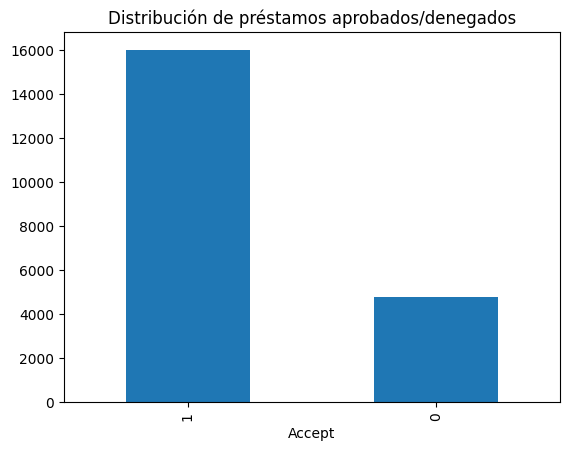

In [3]:
import matplotlib.pyplot as plt

# Distribución de la variable objetivo
train['Accept'].value_counts().plot(kind='bar', title='Distribución de préstamos aprobados/denegados')
plt.show()

## Hipótesis predictivas
- `NoEmp` → más empleados, mayor probabilidad de aprobación
- `NewExist` → empresas nuevas, mayor riesgo de rechazo
- `DisbursementGross` → préstamos grandes, mayor riesgo
- `BalanceGross` → deuda pendiente alta, mayor riesgo
- `CreateJob` y `RetainedJob` → empresas que generan/retienen más empleo, menor riesgo

## Variables que pueden ser ruido
- `id`, `LoanNr_ChkDgt`, `Name`

## Posibles relaciones
- `Bank` / `BankState` pueden influir en aprobación
- `City` / `State` pueden agrupar riesgos similares

## Problemas detectados
- Clases desbalanceadas (`Accept` tiene muchos más 1 que 0)
- Algunos nulos en columnas importantes

# Fase 2: Análisis Exploratorio de Datos (EDA)

**Objetivo:** Explorar el dataset para detectar patrones, relaciones entre variables y problemas que puedan afectar al modelo. Confirmar o ajustar las hipótesis de la Fase 1 y decidir qué columnas y transformaciones usar.

### Estadísticas generales

In [5]:
# Resumen de columnas numéricas y categóricas
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,20768,20768,64afe857c28,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoanNr_ChkDgt,20768.0,NaN,NaN,NaN,4512983261.869318,2610161339.576339,1000144007.0,2298072504.0,3735034006.0,6739156506.25,9994993010.0
Name,20768,19077,SUBWAY,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,20767,1466,CHICAGO,4280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,20768,1,IL,20768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bank,20713,496,JPMORGAN CHASE BANK NATL ASSOC,3027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BankState,20711,42,IL,13002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApprovalDate,20768,5476,30-Jun-05,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApprovalFY,20768,45,2007,2312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NoEmp,20768.0,NaN,NaN,NaN,10.784187,76.659174,0.0,2.0,4.0,10.0,7389.0


### Conclusiones del análisis de la tabla de estadísticas del dataset

Variables irrelevantes o identificadores:

id, LoanNr_ChkDgt, Name → cada fila es única, no aportan información para predecir la aprobación de préstamos, se eliminarán del modelo.

Variables categóricas útiles:

NewExist (tipo de empresa: nueva o existente), UrbanRural (urbano/rural), RevLineCr, LowDoc, State, BankState → pueden influir en el riesgo de crédito.
Algunas tienen valores nulos que habrá que imputar.

Variables numéricas interesantes:

NoEmp (empleados), CreateJob, RetainedJob, DisbursementGross (monto del préstamo) → importantes para evaluar riesgo.
Presentan valores extremos (outliers) que habrá que tratar o transformar.
BalanceGross → siempre 0, no aporta información.

Variable objetivo (Accept):

77% aprobados, 23% no aprobados → dataset desequilibrado, se tendrá que considerar al entrenar modelos.

Problemas detectados:

Valores nulos en varias columnas (City, Bank, BankState, NewExist, RevLineCr, LowDoc, DisbursementDate).
Valores extremos en variables numéricas (DisbursementGross, NoEmp, CreateJob, RetainedJob).
Posible colinealidad entre CreateJob y RetainedJob.

Hipótesis iniciales para predicción:

Empresas nuevas (NewExist=2) podrían tener más riesgo.
Empresas con más empleados (NoEmp) y préstamos más grandes (DisbursementGross) podrían tener mayor probabilidad de aprobación o rechazo, dependiendo de los límites de riesgo.
La ubicación (UrbanRural) y el tipo de crédito (RevLineCr, LowDoc) podrían ser predictores útiles.
Combinar CreateJob y RetainedJob en ratios o sumas podría ser informativo.

## Diagrama de correlaciones (heatmap)

Cada celda muestra la correlación entre dos variables numéricas.

El valor va de -1 a 1:

* 1 → correlación positiva perfecta (cuando una sube, la otra sube)

* 0 → no hay relación lineal

* -1 → correlación negativa perfecta (cuando una sube, la otra baja)

Ver qué variables numéricas podrían estar relacionadas con Accept y cuáles están muy relacionadas entre sí.


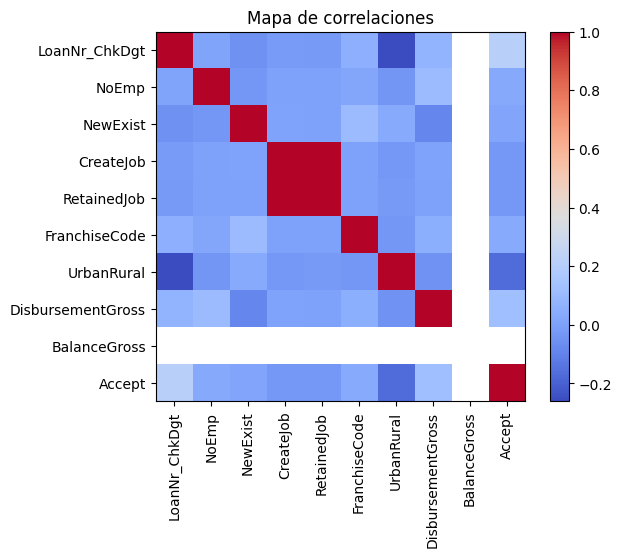

In [7]:
import matplotlib.pyplot as plt
import numpy as np

num_cols = train.select_dtypes(include=['int64','float64'])
corr = num_cols.corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Mapa de correlaciones')
plt.show()

1. Variables redundantes:

* CreateJob y RetainedJob tienen correlación perfecta (1.0).
Esto significa que siempre cambian juntas, así que pueden ser redundantes. Podríamos quedarnos con solo una de ellas para simplificar el modelo.

2. Correlaciones negativas:

* UrbanRural y LoanNr_ChkDgt tienen la correlación negativa más fuerte (-0.26).
Esto indica que el tipo de zona (urbana/rural) podría influir inversamente en alguna característica del préstamo.

3. Correlación con la variable objetivo (Accept):

Todas las correlaciones con Accept son bajas (máximo ~0.21).
Esto sugiere que ninguna variable por sí sola predice bien la aceptación de un préstamo, por lo que el modelo tendrá que combinar varias variables para funcionar bien.

4. Independencia entre variables:

La mayoría de las variables tienen correlaciones cercanas a 0.

Esto significa que no dependen mucho entre sí, lo que puede ser positivo porque reduce problemas de colinealidad, salvo los casos de CreateJob y RetainedJob.

## Histogramas (distribución de variables numéricas)

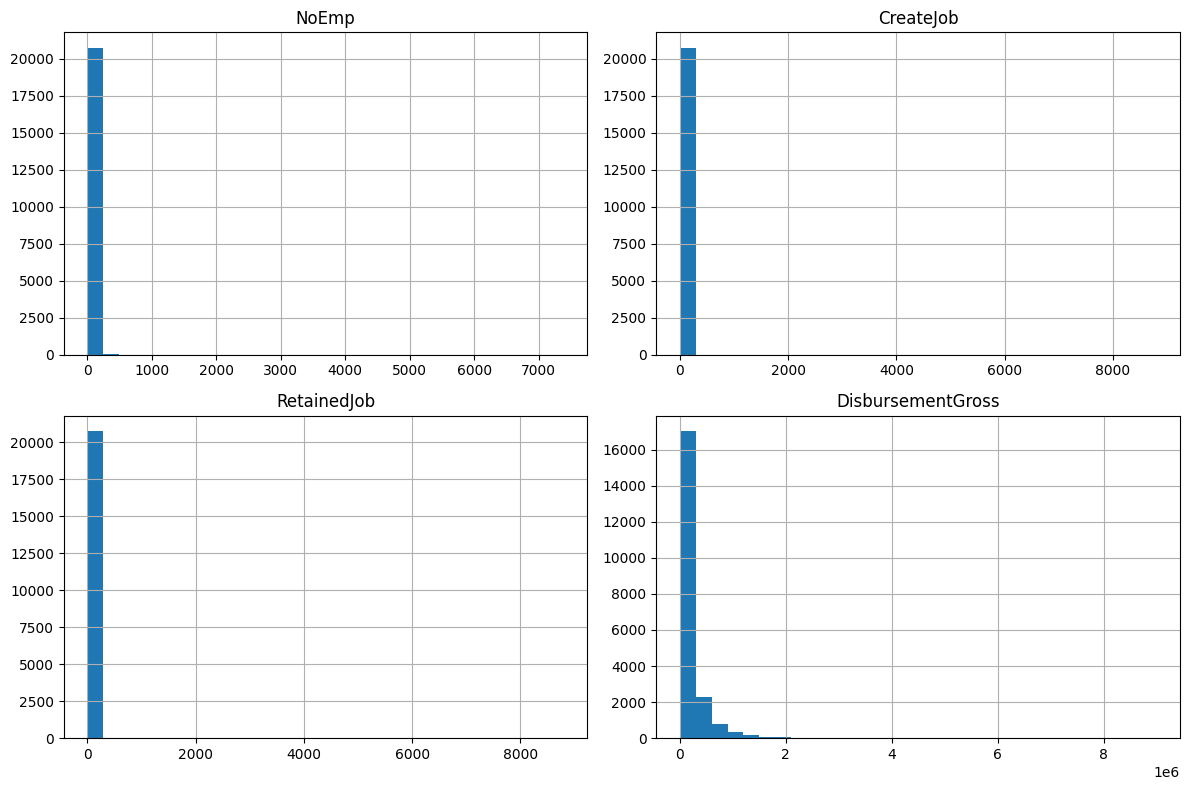

In [8]:
num_cols = ['NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    train[col].hist(bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

Se observa que la mayoría de las variables (`NoEmp`, `CreateJob`, `RetainedJob`) presentan una **alta concentración de valores cercanos a 0**, lo que indica que la mayoría de las empresas del dataset son pequeñas y generan pocos empleos.

En el caso de `DisbursementGross`, la distribución es **fuertemente asimétrica (sesgada hacia la derecha)**. Esto se observa en una gran concentración de valores bajos y la presencia de algunas observaciones con valores muy altos. Este comportamiento indica la existencia de **outliers**, es decir, préstamos de gran tamaño que son poco frecuentes.

Este tipo de distribución puede afectar negativamente a ciertos modelos de aprendizaje automático,

## Análisis de variables categóricas: UrbanRural y NewExist

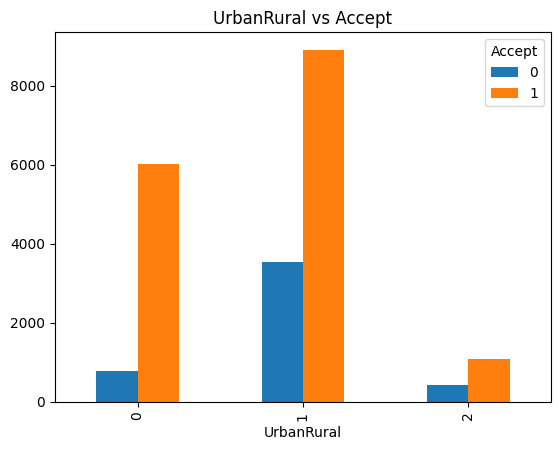

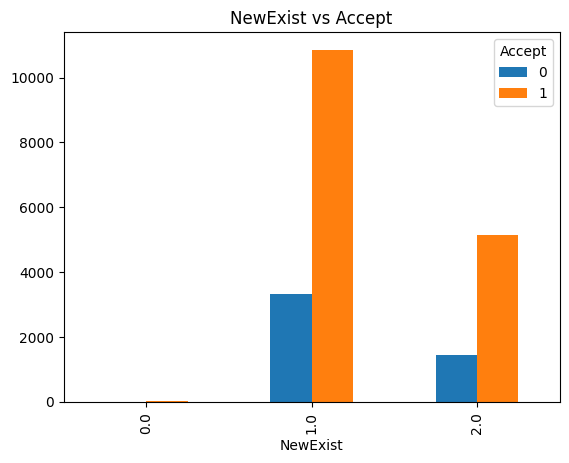

In [12]:
import matplotlib.pyplot as plt

# UrbanRural
train.groupby(['UrbanRural', 'Accept']).size().unstack().plot(kind='bar')
plt.title('UrbanRural vs Accept')
plt.show()

# NewExist
train.groupby(['NewExist', 'Accept']).size().unstack().plot(kind='bar')
plt.title('NewExist vs Accept')
plt.show()

Aunque UrbanRural y NewExist muestran diferencias, las tasas de aceptación no son radicalmente distintas:

Para UrbanRural, las tasas de aprobación oscilan entre 71 % y 88 %, no hay un grupo con rechazo masivo.

Para NewExist, las tasas van de 76 % a 90 %, de nuevo ninguna categoría tiene un riesgo extremo.

Conclusión práctica para el notebook:
Estas variables muestran cierta tendencia, pero por sí solas no son decisivas. Probablemente el modelo necesitará combinar varias variables y considerar interacciones para predecir bien la aprobación de un préstamo.

## Conclusión final

### 1. Variables irrelevantes
- `id`, `LoanNr_ChkDgt`, `Name` → cada fila es única, no aportan información para predecir la aprobación de préstamos y se eliminarán del modelo.
- `BalanceGross` → constante (0 en todas las filas), no aporta información.

### 2. Variables categóricas útiles
- `NewExist` (tipo de empresa: nueva o existente)  
- `UrbanRural` (urbano/rural)  
- `RevLineCr`, `LowDoc`, `State`, `BankState`  
- Algunas columnas tienen valores nulos que habrá que imputar antes del modelado.

### 3. Variables numéricas importantes
- `NoEmp`, `CreateJob`, `RetainedJob` → concentradas en valores bajos, reflejan que la mayoría de las empresas son pequeñas. No presentan outliers extremos.  
- `DisbursementGross` → distribución sesgada hacia la derecha con outliers claros: préstamos muy grandes poco frecuentes que podrían afectar al modelo.  

### 4. Variable objetivo
- `Accept`: 77% aprobados, 23% no aprobados → dataset desequilibrado, se tendrá que considerar al entrenar modelos.

### 5. Correlaciones y relaciones
- `CreateJob` y `RetainedJob` tienen correlación perfecta → podrían ser redundantes, se podría usar solo una o combinarlas.  
- Correlaciones con `Accept` bajas (máx. ~0.21) → ninguna variable predice sola la aceptación; se necesitará combinar varias variables.  
- `UrbanRural` y `NewExist` muestran diferencias leves en tasas de aceptación, pero no son determinantes por sí solas.

### 6. Distribución de variables
- Variables numéricas concentradas cerca de 0.  
- `DisbursementGross` presenta outliers que conviene considerar en preprocesamiento.  

### 7. Conclusión práctica
- Las zonas urbanas concentran la mayoría de solicitudes, pero no influyen radicalmente en la probabilidad de aprobación.  
- Los negocios existentes (`NewExist=1`) tienen mayor probabilidad de ser aprobados que los nuevos, aunque la diferencia no es extrema.  
- Los modelos predictivos deberán considerar combinaciones de variables y posibles transformaciones de `DisbursementGross` para manejar los outliers.  


# RevLineCr
La variable `RevLineCr` debería ser binaria (Y/N), indicando si el préstamo es una línea de crédito rotativa.
Sin embargo, se observan valores no estándar y valores faltantes.

In [13]:
# Conteo de valores
rev_counts = train['RevLineCr'].value_counts(dropna=False)

# Porcentajes
rev_pct = train['RevLineCr'].value_counts(normalize=True, dropna=False) * 100

# Juntar en tabla
rev_table = pd.DataFrame({
    'Count': rev_counts,
    'Percentage (%)': rev_pct.round(2)
})

rev_table

,Count,Percentage (%)
RevLineCr,,
N,10037,48.33
Y,5277,25.41
0,5046,24.30
T,281,1.35
NaN,126,0.61
Q,1,0.00


### Observaciones

- Los valores esperados (`Y` y `N`) representan aproximadamente el 73% del dataset.
- Existe un porcentaje muy relevante de valores no estándar, principalmente `0` (24.30%), que no puede ser ignorado.
- Otros valores como `T` y `Q` son minoritarios pero indican inconsistencias en los datos.
- Los valores faltantes son pocos (0.61%), pero también deben considerarse.

### Conclusión

Dado que los valores no estándar representan una proporción significativa del dataset (especialmente el valor `0`), no es adecuado eliminarlos ni forzarlos directamente a `Y` o `N`.

Por tanto, se decide:

- Crear una variable categórica limpia (`RevLineCr_clean`) con las categorías:
  - `Y`
  - `N`
  - `UNKNOWN` (para valores no estándar como `0`, `T`, `Q`)
  - `MISSING` (para valores nulos)

- Crear variables adicionales:
  - `RevLineCr_is_nonstandard` → indica si el valor es no estándar
  - `RevLineCr_is_missing` → indica si el valor es nulo

Este enfoque permite capturar información adicional sobre la calidad de los datos y posibles patrones asociados al riesgo del préstamo.

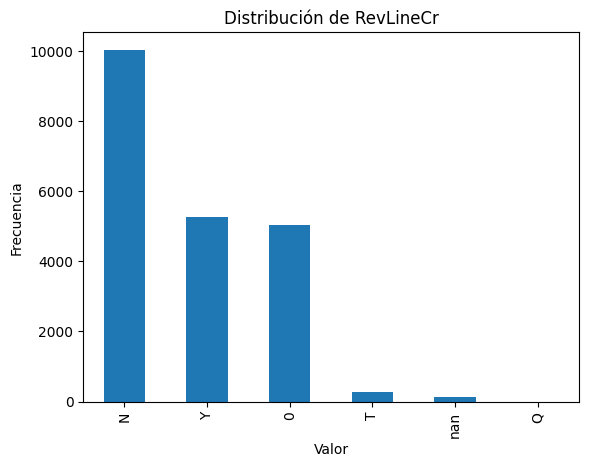

In [14]:
import matplotlib.pyplot as plt

rev_counts.plot(kind='bar')
plt.title('Distribución de RevLineCr')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

In [15]:
# Crear variable limpia
train['RevLineCr_clean'] = train['RevLineCr'].replace({
    'Y': 'Y',
    'N': 'N',
    '0': 'UNKNOWN',
    'T': 'UNKNOWN',
    'Q': 'UNKNOWN'
})

# Missing
train['RevLineCr_clean'] = train['RevLineCr_clean'].fillna('MISSING')

# Flags
train['RevLineCr_is_nonstandard'] = train['RevLineCr'].isin(['0','T','Q']).astype(int)
train['RevLineCr_is_missing'] = train['RevLineCr'].isnull().astype(int)

In [16]:
train[['RevLineCr','RevLineCr_clean','RevLineCr_is_nonstandard','RevLineCr_is_missing']].sample(10)

,RevLineCr,RevLineCr_clean,RevLineCr_is_nonstandard,RevLineCr_is_missing
6635,N,N,0,0
1744,N,N,0,0
2865,Y,Y,0,0
8810,0,UNKNOWN,1,0
12116,N,N,0,0
14500,NaN,MISSING,0,1
19005,N,N,0,0
11735,0,UNKNOWN,1,0
6603,N,N,0,0
3185,Y,Y,0,0


In [17]:
train[train['RevLineCr'].isnull()][
    ['RevLineCr','RevLineCr_clean','RevLineCr_is_nonstandard','RevLineCr_is_missing']
]

,RevLineCr,RevLineCr_clean,RevLineCr_is_nonstandard,RevLineCr_is_missing
412,NaN,MISSING,0,1
415,NaN,MISSING,0,1
858,NaN,MISSING,0,1
861,NaN,MISSING,0,1
1120,NaN,MISSING,0,1
...,...,...,...,...
19821,NaN,MISSING,0,1
19866,NaN,MISSING,0,1
20028,NaN,MISSING,0,1
20124,NaN,MISSING,0,1


In [18]:
train['RevLineCr_clean'].value_counts(normalize=True) * 100

RevLineCr_clean
N          48.329160
UNKNOWN    25.654854
Y          25.409284
MISSING     0.606703
Name: proportion, dtype: float64

### Análisis de valores faltantes en RevLineCr

Para evaluar si los valores MISSING, al tener poco porcentaje, contienen información relevante, se analiza su tasa de aprobación mediante el siguiente cálculo:

In [19]:
rev_accept = train.groupby('RevLineCr_clean')['Accept'].mean() * 100
rev_accept = rev_accept.round(1)
display(rev_accept)

RevLineCr_clean
MISSING    96.8
N          80.8
UNKNOWN    80.1
Y          66.6
Name: Accept, dtype: float64

Se observan diferencias claras entre las categorías:

* MISSING presenta una tasa de aprobación extremadamente alta, lo que indica que los valores faltantes contienen una señal muy fuerte.
* N y UNKNOWN tienen comportamientos muy similares (≈80 %), lo que sugiere que podrían estar capturando perfiles parecidos.
* Y presenta una tasa de aprobación significativamente menor, siendo la categoría con menor probabilidad de aceptación.

Dado que existen diferencias significativas entre las categorías, especialmente en el caso de MISSING, no es adecuado eliminar ni agrupar estas categorías sin perder información relevante.

### Distribución de RevLineCr tras limpieza

Después de agrupar los valores no estándar y los faltantes:

- N: 48.3 %
- Y: 25.4 %
- UNKNOWN: 25.7 %  
- MISSING: 0.6 %

Se observa que una parte significativa de los datos originales (0/T/Q) ahora está en `UNKNOWN`, lo que permite al modelo aprender patrones asociados a valores no estándar sin perder información.  
Los valores nulos permanecen en `MISSING`, preservando la señal de falta de información.

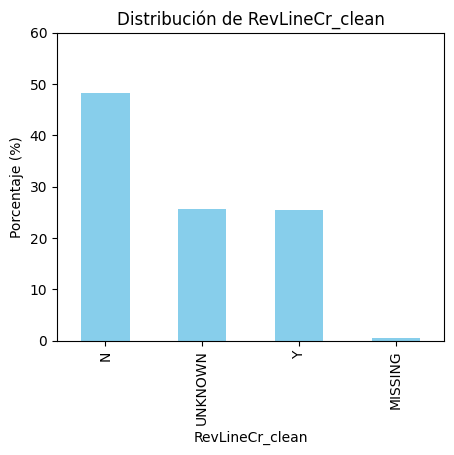

In [20]:
import matplotlib.pyplot as plt

# Contar proporciones
revline_counts = train['RevLineCr_clean'].value_counts(normalize=True) * 100

# Gráfico de barras simple
revline_counts.plot(kind='bar', color='skyblue', figsize=(5,4))
plt.ylabel('Porcentaje (%)')
plt.title('Distribución de RevLineCr_clean')
plt.ylim(0, 60)  
plt.show()

# Opción B

In [21]:
# Crear variable limpia según Opción B
train['RevLineCr_clean_A'] = train['RevLineCr'].replace({
    'Y': 'Y',
    'N': 'N',
    '0': 'UNKNOWN',
    'T': 'UNKNOWN',
    'Q': 'UNKNOWN'
})

# Asignar valores faltantes
train['RevLineCr_clean_A'] = train['RevLineCr_clean_A'].fillna('MISSING')

# Mostrar conteo de categorías
train['RevLineCr_clean_A'].value_counts(normalize=True) * 100

RevLineCr_clean_A
N          48.329160
UNKNOWN    25.654854
Y          25.409284
MISSING     0.606703
Name: proportion, dtype: float64

La opción A se considera más robusta ya que, además de agrupar los valores en categorías limpias, permite al modelo capturar información adicional sobre si un valor es no estándar o missing, lo cual puede ser relevante en problemas de riesgo crediticio.

# LowDoc

La variable LowDoc indica si el préstamo pertenece al programa de documentación mínima:
- Y → Yes
- N → No

Sin embargo, se observan valores no estándar (0, S, C, A, R, etc.) y valores missing, lo que requiere un proceso de limpieza antes de su uso en modelos.

In [22]:
# Conteo de valores
lowdoc_counts = train['LowDoc'].value_counts(dropna=False)

# Porcentajes
lowdoc_pct = train['LowDoc'].value_counts(normalize=True, dropna=False) * 100

# Tabla resumen
lowdoc_table = pd.DataFrame({
    'Count': lowdoc_counts,
    'Percentage (%)': lowdoc_pct.round(2)
})

lowdoc_table

,Count,Percentage (%)
LowDoc,,
N,16903,81.39
Y,3778,18.19
NaN,36,0.17
0,26,0.13
S,8,0.04
C,7,0.03
A,6,0.03
R,4,0.02


### Observaciones

- N representa el 81.4 % del dataset.
- Y representa el 18.2 %.
- Los valores no estándar (0, S, C, A, R) y los valores missing son muy poco frecuentes (≈0.4 % en total).

### Conclusión

A diferencia de otras variables como RevLineCr, los valores no estándar en LowDoc son marginales y no representan una proporción significativa del dataset.

Por tanto, existen dos enfoques posibles:

- Opción A (simple): agrupar valores no estándar y faltantes en una única categoría (UNKNOWN/MISSING).
- Opción B (robusta): mantener UNKNOWN y MISSING como categorías separadas y añadir variables indicadoras.

En este caso, dado el bajo porcentaje de valores no estándar, la opción simple podría ser suficiente. No obstante, se mantiene la opción B por consistencia con otras variables y para permitir al modelo capturar posibles señales de calidad de datos.

La decisión final se validará en la fase de modelado mediante validación cruzada.

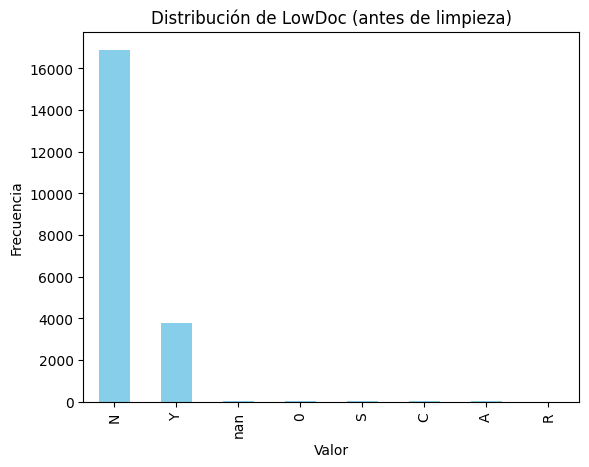

In [23]:
# Conteo de valores, incluyendo nulos
lowdoc_counts = train['LowDoc'].value_counts(dropna=False)

# Gráfico de barras sencillo
lowdoc_counts.plot(kind='bar', color='skyblue')
plt.title('Distribución de LowDoc (antes de limpieza)')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

## LowDoc – Opción A (simplificada)

Dado que la variable LowDoc es esencialmente binaria (Y/N) y los valores no estándar representan una proporción muy pequeña del dataset (~0.4 %), se puede aplicar una estrategia de limpieza simple.

### Estrategia

- Mantener:
  - Y → Yes
  - N → No

- Agrupar valores no estándar (0, S, C, A, R) en:
  - UNKNOWN

- Agrupar valores nulos en:
  - MISSING

### Ventajas

- Simplicidad en el tratamiento de la variable.
- Menor número de columnas para el modelo.
- Adecuado cuando los valores no estándar son poco frecuentes.

In [24]:
# Crear variable limpia (opción simple)
train['LowDoc_clean_A'] = train['LowDoc'].replace({
    'Y': 'Y',
    'N': 'N',
    '0': 'UNKNOWN',
    'S': 'UNKNOWN',
    'C': 'UNKNOWN',
    'A': 'UNKNOWN',
    'R': 'UNKNOWN'
})

# Missing
train['LowDoc_clean_A'] = train['LowDoc_clean_A'].fillna('MISSING')

# Ver algunos ejemplos
train[['LowDoc','LowDoc_clean_A']].sample(10)

,LowDoc,LowDoc_clean_A
15200,N,N
16638,N,N
7880,Y,Y
17560,Y,Y
9542,N,N
10344,N,N
6809,N,N
9886,N,N
6929,N,N
8896,Y,Y


In [25]:
train['LowDoc_clean_A'].value_counts(normalize=True) * 100

LowDoc_clean_A
N          81.389638
Y          18.191448
UNKNOWN     0.245570
MISSING     0.173344
Name: proportion, dtype: float64

### Análisis de la variable objetivo (Accept) por categoría de LowDoc

Para evaluar si UNKNOWN y MISSING se pueden juntar al tener un bajo porcentaje, se analiza la tasa de aprobación en cada categoría mediante el siguiente cálculo:

In [26]:
lowdoc_accept = train.groupby('LowDoc_clean_A')['Accept'].mean() * 100
lowdoc_accept = lowdoc_accept.round(1)
display(lowdoc_accept)

LowDoc_clean_A
MISSING    47.2
N          74.5
UNKNOWN    80.4
Y          89.3
Name: Accept, dtype: float64

Se observan diferencias muy significativas entre las categorías:

* **Y** presenta la mayor tasa de aprobación, lo que indica que los préstamos con documentación reducida tienden a ser aprobados con mayor frecuencia.
* **N** tiene una tasa intermedia.
* **UNKNOWN** presenta una tasa relativamente alta, incluso superior a N.
* **MISSING** tiene una tasa de aprobación mucho menor, lo que sugiere un mayor riesgo o incertidumbre asociada a estos casos.

Dado que las categorías **UNKNOWN y MISSING** presentan comportamientos muy distintos respecto a la variable objetivo, **no es adecuado agruparlas en una única categoría.**

Hacerlo implicaría perder información relevante para el modelo, ya que se estarían mezclando patrones de comportamiento diferentes.

Por tanto, se decide mantener todas las categorías separadas, permitiendo que el modelo capture correctamente estas diferencias.

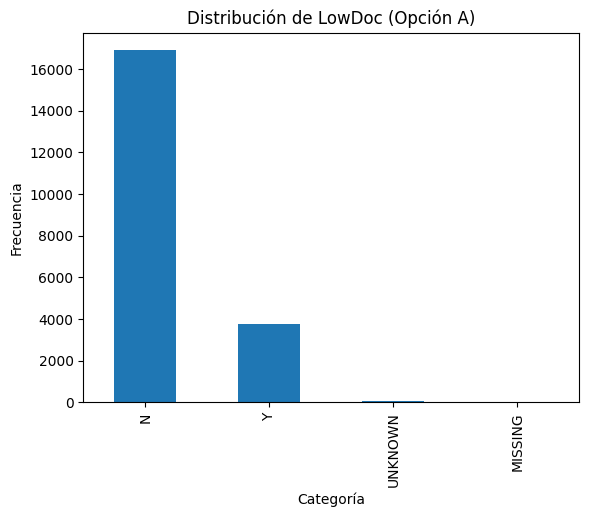

In [27]:
import matplotlib.pyplot as plt

train['LowDoc_clean_A'].value_counts().plot(kind='bar')
plt.title('Distribución de LowDoc (Opción A)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.show()

### Distribución tras limpieza (Opción A)

- La gran mayoría de los valores se concentran en las categorías Y y N.
- Los valores no estándar y faltantes se agrupan en UNKNOWN y MISSING, respectivamente.
- Dado que estos valores representan una proporción muy pequeña, su impacto en el modelo será limitado.

### Conclusión

La opción A proporciona una solución simple y suficiente para esta variable, reduciendo complejidad sin pérdida significativa de información.

## LowDoc – Opción B (codificación robusta)

Aunque los valores no estándar en LowDoc representan una proporción muy pequeña del dataset (~0.4%), se opta por una estrategia robusta que permita capturar posibles señales relacionadas con la calidad de los datos.

### Estrategia

Se crea una variable categórica limpia:

- Y préstamo con documentación reducida
- N préstamo normal
- UNKNOWN valores no estándar (0, S, C, A, R)
- MISSING valores nulos

Además, se añaden variables indicadoras:

- LowDoc_is_nonstandard 1 si el valor original es no estándar
- LowDoc_is_missing 1 si el valor original es nulo

### Ventajas

- Permite al modelo diferenciar entre valores válidos, no estándar y faltantes.
- Mantiene toda la información del dataset sin eliminar filas.
- Puede capturar patrones de riesgo asociados a la calidad de los datos.

### Nota
Aunque el impacto de los valores no estándar es bajo en esta variable, se mantiene este enfoque por consistencia con otras variables como RevLineCr.

In [28]:
# Variable limpia
train['LowDoc_clean'] = train['LowDoc'].replace({
    'Y': 'Y',
    'N': 'N',
    '0': 'UNKNOWN',
    'S': 'UNKNOWN',
    'C': 'UNKNOWN',
    'A': 'UNKNOWN',
    'R': 'UNKNOWN'
})

# Missing
train['LowDoc_clean'] = train['LowDoc_clean'].fillna('MISSING')

# Flags
train['LowDoc_is_nonstandard'] = train['LowDoc'].isin(['0','S','C','A','R']).astype(int)
train['LowDoc_is_missing'] = train['LowDoc'].isnull().astype(int)

train[['LowDoc','LowDoc_clean','LowDoc_is_nonstandard','LowDoc_is_missing']].sample(10)


,LowDoc,LowDoc_clean,LowDoc_is_nonstandard,LowDoc_is_missing
12514,N,N,0,0
7951,N,N,0,0
19334,N,N,0,0
17694,N,N,0,0
12355,N,N,0,0
5980,N,N,0,0
1463,N,N,0,0
6435,Y,Y,0,0
19466,N,N,0,0
7703,N,N,0,0


* Modelos de árbol (Random Forest, XGBoost, LightGBM, CatBoost, etc.):
Suelen manejar categorías directamente, incluso con valores “UNKNOWN” o faltantes.
Por eso la Opción A puede ser suficiente: RevLineCr_clean y LowDoc_clean como categorías, sin necesidad de columnas indicadoras.

* Modelos lineales o basados en regresión (Logistic Regression, Linear SVM, etc.):
No manejan categorías de forma natural.
Aquí la Opción B es mejor: usar *_clean codificado one-hot y añadir las columnas *_is_nonstandard y *_is_missing como indicadores para que el modelo pueda capturar la señal de calidad de los datos.